In [15]:
from sklearn.datasets import make_blobs,load_iris
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
data=load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
print(df)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


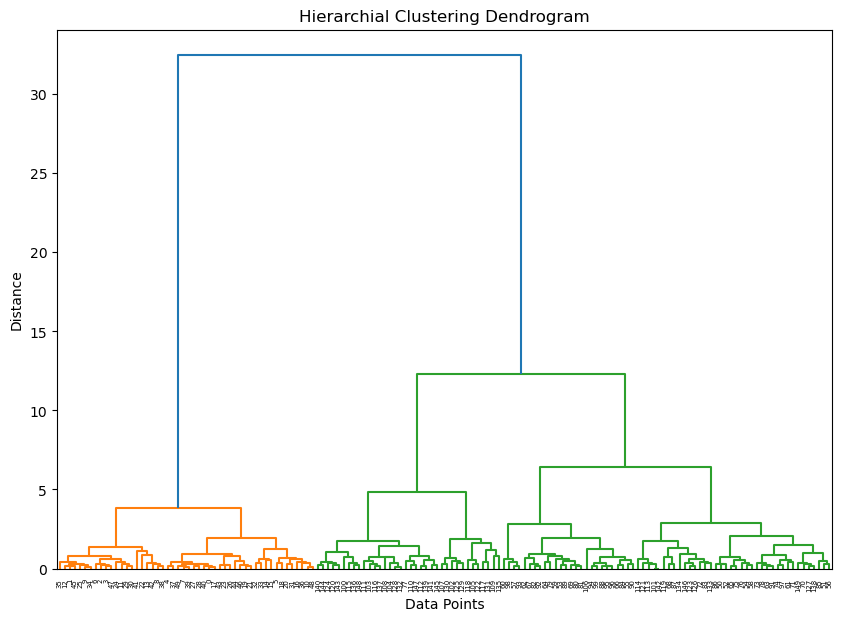

In [17]:
z=sch.linkage(df,method='ward')
plt.figure(figsize=(10,7))
sch.dendrogram(z)
plt.title('Hierarchial Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [21]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import fcluster
max_d=3
clusters=fcluster(z,max_d,criterion='distance')
print(clusters)

[2 1 1 1 2 2 1 2 1 1 2 1 1 1 2 2 2 2 2 2 2 2 1 2 1 1 2 2 2 1 1 2 2 2 1 1 2
 2 1 2 2 1 1 2 2 1 2 1 2 2 6 6 6 5 6 5 6 5 6 5 5 6 5 6 5 6 5 5 6 5 6 6 6 6
 6 6 6 3 6 5 5 5 5 6 5 6 6 6 5 5 5 6 5 5 5 5 5 6 5 5 3 6 4 3 3 4 5 4 3 4 3
 3 3 6 6 3 3 4 4 6 3 6 4 6 3 4 6 6 3 4 4 4 3 6 6 4 3 3 6 3 3 3 6 3 3 3 6 3
 3 6]


In [27]:
print("Make BLob Dataset : ")
X,y=make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    n_features=2,
    random_state=42)
data=pd.DataFrame(X,columns=["P","Q"])
print(data.head())


           P         Q
0  -9.297689  6.473679
1  -9.698741  6.938967
2  -1.686653  7.793442
3  -7.097308 -5.781333
4 -10.876452  6.315437


Visualizing the dataset : 


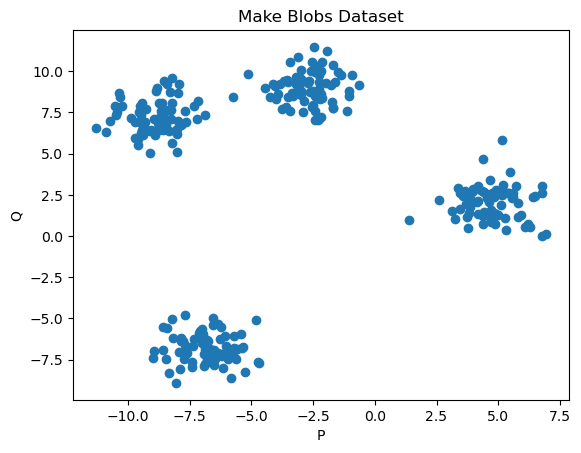

In [29]:
print("Visualizing the dataset : ")
plt.scatter(X[:,0],X[:,1])
plt.xlabel("P")
plt.ylabel("Q")
plt.title("Make Blobs Dataset")
plt.show()

Agglomerative Clustering


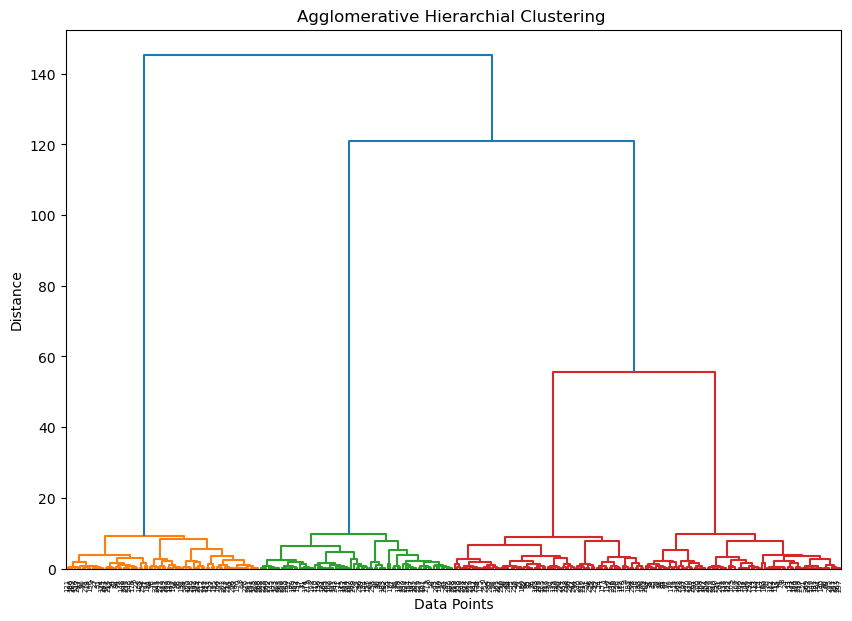

In [31]:
print("Agglomerative Clustering")
linkage_matrix=sch.linkage(X,method='ward')
plt.figure(figsize=(10,7))
sch.dendrogram(linkage_matrix)
plt.title("Agglomerative Hierarchial Clustering ")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [35]:
model=AgglomerativeClustering(n_clusters=4,linkage='ward')
labels=model.fit_predict(X)
data["clusters"]=labels
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


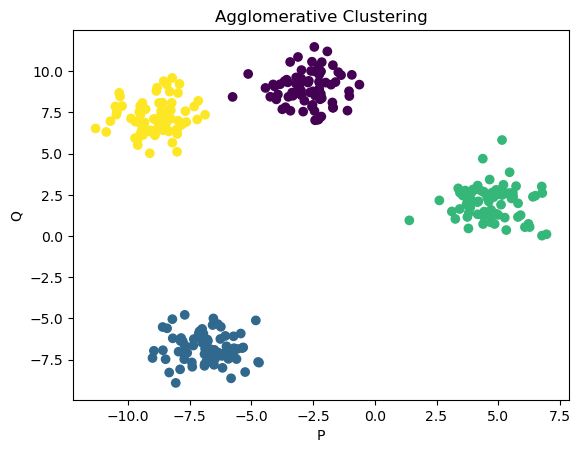

In [37]:
plt.scatter(X[:,0],X[:,1],c=labels)
plt.xlabel("P")
plt.ylabel("Q")
plt.title("Agglomerative Clustering")
plt.show()

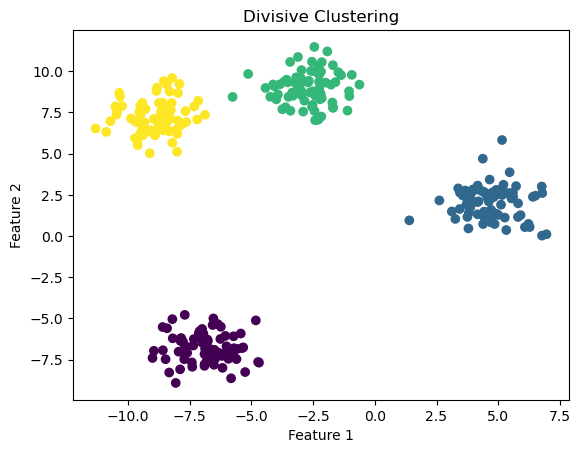

In [43]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Create dataset
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

# Start with one cluster containing all points
clusters = [np.arange(len(X))]

# Split until we have 4 clusters
while len(clusters) < 4:

    # Find the largest cluster
    largest_index = max(
        range(len(clusters)),
        key=lambda i: len(clusters[i])
    )

    # Remove and get the largest cluster
    largest_cluster = clusters.pop(largest_index)

    # Get data belonging to that cluster
    data = X[largest_cluster]

    # Split into 2
    model = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(data)

    # Create two new clusters
    cluster_1 = largest_cluster[labels == 0]
    cluster_2 = largest_cluster[labels == 1]

    # Add the two clusters
    clusters.append(cluster_1)
    clusters.append(cluster_2)


# Create final labels
final_labels = np.zeros(len(X), dtype=int)

for i, cluster in enumerate(clusters):
    final_labels[cluster] = i


# Plot
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=final_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Divisive Clustering")
plt.show()